*

                LOGISTIC REGRESSION USING CHURN DATASET

23MID0019
JEEVANTH S


*

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, log_loss

# Set plot style
%matplotlib inline
sns.set(style="whitegrid")

In [14]:
# Load the dataset
df = pd.read_csv('D:/Sem-06/ML for DS/LAB/05-02-2026/ChurnData.csv')

# Display the first few rows and column information
print(df.head())
print(df.info())

   tenure   age  address  income   ed  employ  equip  callcard  wireless  \
0    11.0  33.0      7.0   136.0  5.0     5.0    0.0       1.0       1.0   
1    33.0  33.0     12.0    33.0  2.0     0.0    0.0       0.0       0.0   
2    23.0  30.0      9.0    30.0  1.0     2.0    0.0       0.0       0.0   
3    38.0  35.0      5.0    76.0  2.0    10.0    1.0       1.0       1.0   
4     7.0  35.0     14.0    80.0  2.0    15.0    0.0       1.0       0.0   

   longmon  ...  pager  internet  callwait  confer  ebill  loglong  logtoll  \
0     4.40  ...    1.0       0.0       1.0     1.0    0.0    1.482    3.033   
1     9.45  ...    0.0       0.0       0.0     0.0    0.0    2.246    3.240   
2     6.30  ...    0.0       0.0       0.0     1.0    0.0    1.841    3.240   
3     6.05  ...    1.0       1.0       1.0     1.0    1.0    1.800    3.807   
4     7.10  ...    0.0       0.0       1.0     1.0    0.0    1.960    3.091   

   lninc  custcat  churn  
0  4.913      4.0    1.0  
1  3.497      

In [15]:
# Selection of features for the model
X = df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']].values
y = df['churn'].values.astype('int')

# Standardizing the feature set
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature set shape:", X.shape)
print("Target set shape:", y.shape)

Feature set shape: (200, 7)
Target set shape: (200,)


In [16]:
# Splitting the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (160, 7) (160,)
Test set: (40, 7) (40,)


In [17]:
# Initialize and fit the Logistic Regression model
# C=0.01 is the regularization strength; solver='liblinear' is good for small datasets
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train, y_train)

# Predict churn (0 or 1) for the test set
yhat = LR.predict(X_test)

# Predict probabilities (needed for Log Loss calculation)
yhat_prob = LR.predict_proba(X_test)


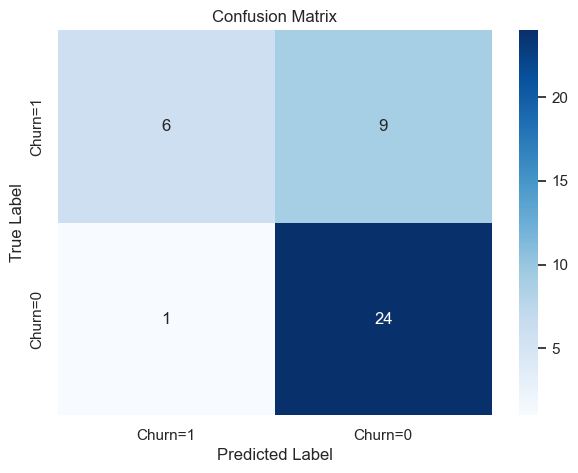

In [18]:
# Compute confusion matrix
cm = confusion_matrix(y_test, yhat, labels=[1, 0])

# Plotting the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Churn=1', 'Churn=0'], 
            yticklabels=['Churn=1', 'Churn=0'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [19]:
# Generate Performance Matrix (Classification Report)
print("Classification Report:")
print(classification_report(y_test, yhat))

# Calculate Log Loss
ll = log_loss(y_test, yhat_prob)
print(f"Log Loss: {ll:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.96      0.83        25
           1       0.86      0.40      0.55        15

    accuracy                           0.75        40
   macro avg       0.79      0.68      0.69        40
weighted avg       0.78      0.75      0.72        40

Log Loss: 0.6017


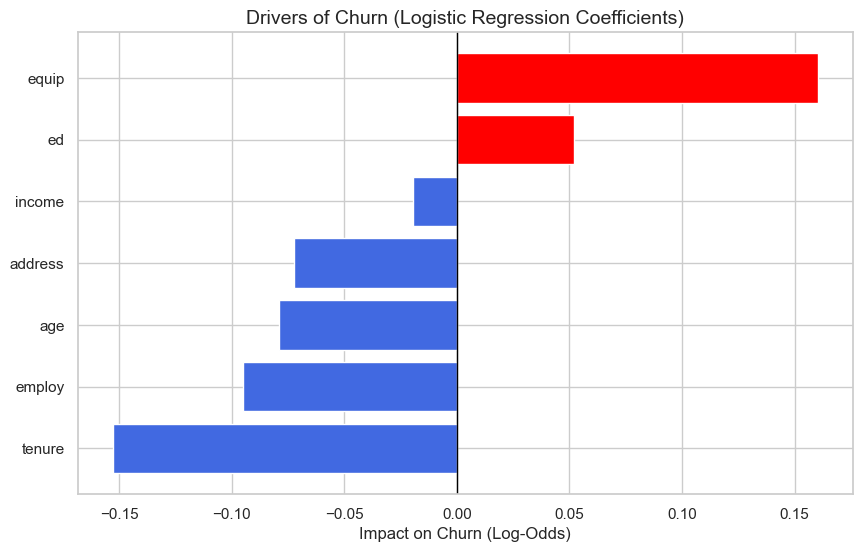

In [20]:
feature_names = ['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']
coefficients = LR.coef_[0]
importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
importance_df = importance_df.sort_values(by='Coefficient')

# Plotting
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'royalblue' for x in importance_df['Coefficient']]
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
plt.title('Drivers of Churn (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Impact on Churn (Log-Odds)', fontsize=12)
plt.axvline(0, color='black', lw=1)
plt.show()